   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 3.3 MB/s eta 0:00:00
  Підготовка середовища Kaggle: Завантаження медіа та моделей...
[ІНФО] Завантаження yolo-tiny.h5...
[ІНФО] Завантаження tiny-yolov3.pt...
[ІНФО] Завантаження fruits.jpg...
[ІНФО] Завантаження 21438-317457608_medium.mp4...
[УСПІХ] Усі файли підготовлені!

  АВТОМАТИЗОВАНИЙ ЗАПУСК ЛАБОРАТОРНОЇ РОБОТИ №5

[КРОК 1/2] Запуск розпізнавання на фото...
[IMAGE] Початок обробки зображення...

--- Знайдені об'єкти на фото ---
banana: 99.97%
banana: 99.95%
apple: 99.84%
apple: 99.01%
orange: 97.86%
orange: 72.14%
orange: 63.57%
orange: 80.04%
orange: 76.71%
orange: 98.57%
[IMAGE] Обробку завершено. Результат збережено у: ./lab05/output/newimage.jpg

[КРОК 2/2] Запуск розпізнавання на відео...

[VIDEO] Початок обробки відео (це може зайняти час)...


OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


[VIDEO] Відео успішно оброблено та збережено у: ./lab05/output/new_video.avi
[VIDEO] Екстракція кадрів для демонстрації...

Усі етапи лабораторної роботи виконано успішно!

--- Відображення загальної сітки зображень ---


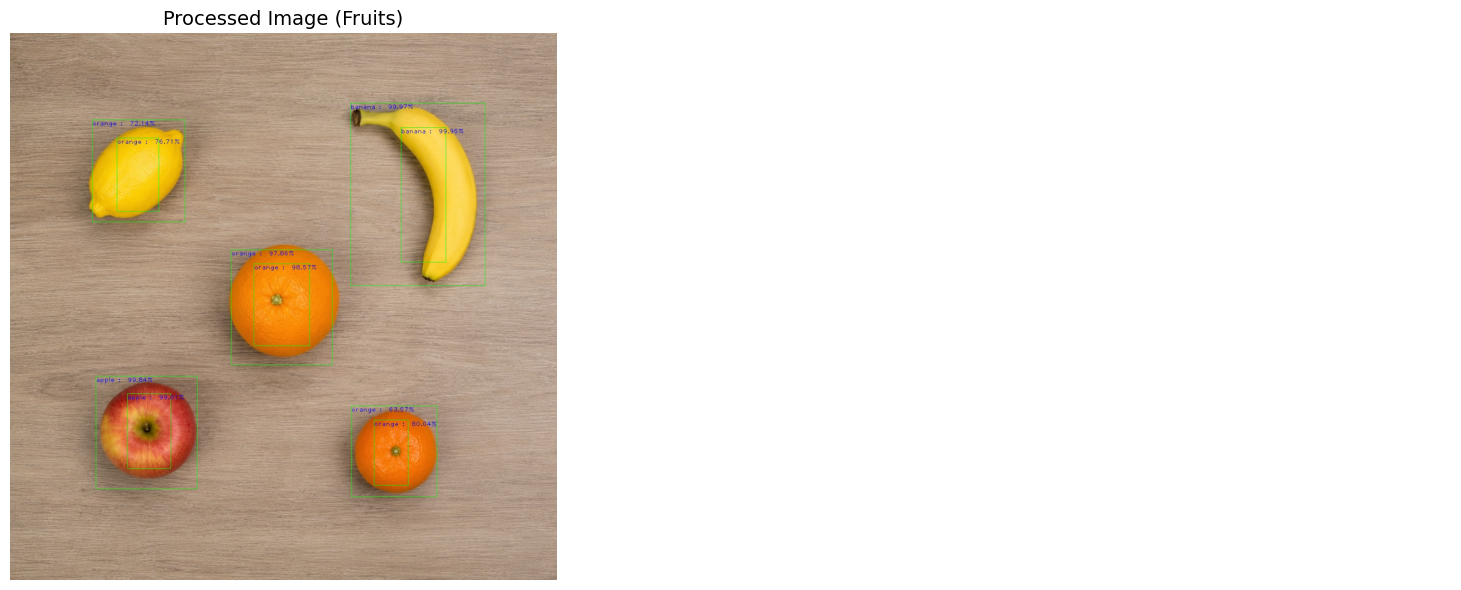


--- Відображення кожного зображення окремо ---



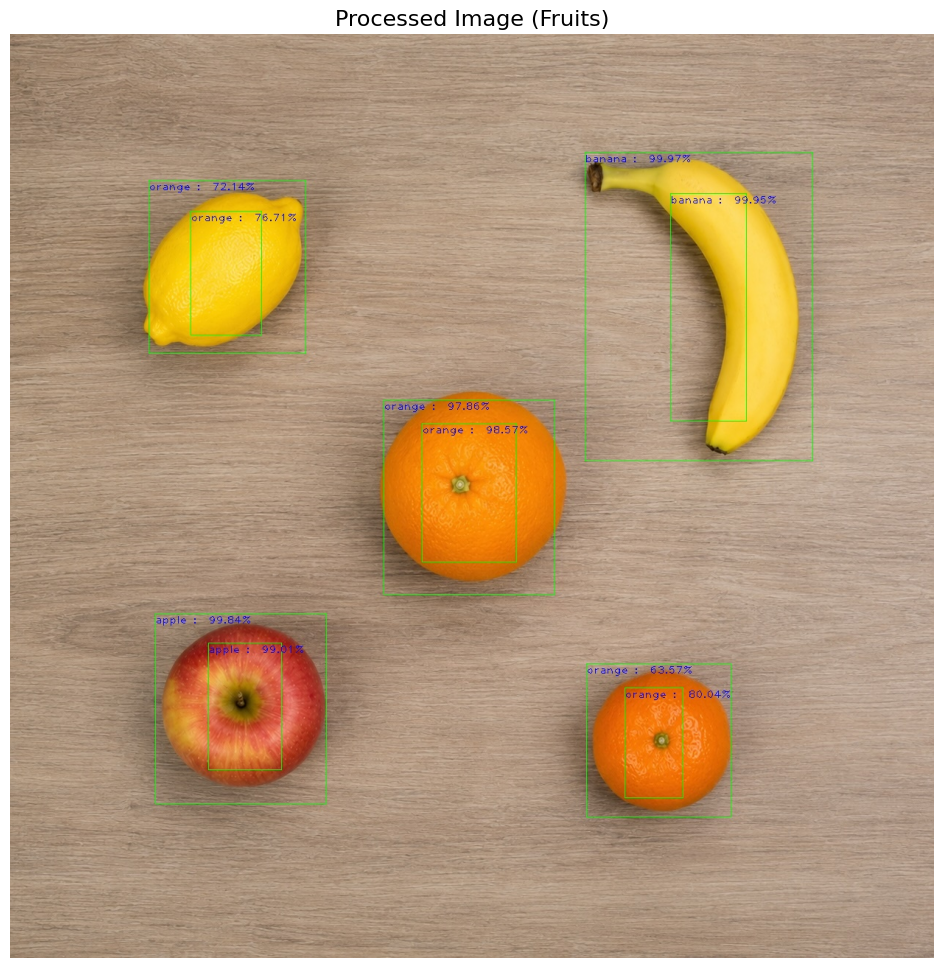

In [1]:
# Запустіть цей рядок один раз у Kaggle, щоб встановити бібліотеку ImageAI
!pip install imageai --quiet

import os
import cv2
import urllib.request
import matplotlib.pyplot as plt
from imageai.Detection import ObjectDetection, VideoObjectDetection

print("=" * 70)
print("  Підготовка середовища Kaggle: Завантаження медіа та моделей...")
print("=" * 70)

# ==============================================================================
# КОНФІГУРАЦІЯ
# ==============================================================================
USE_LEGACY_H5 = False
LAB_PATH = "./lab05"
OUTPUT_DIR = os.path.join(LAB_PATH, "output")

H5_MODEL_PATH = os.path.join(LAB_PATH, "yolo-tiny.h5")
PT_MODEL_PATH = os.path.join(LAB_PATH, "tiny-yolov3.pt")
INPUT_IMAGE_PATH = os.path.join(LAB_PATH, "fruits.jpg")
OUTPUT_IMAGE_PATH = os.path.join(OUTPUT_DIR, "newimage.jpg")
INPUT_VIDEO_PATH = os.path.join(LAB_PATH, "21438-317457608_medium.mp4")
OUTPUT_VIDEO_PATH = os.path.join(OUTPUT_DIR, "new_video") # ImageAI автоматично додасть розширення (наприклад, .avi)

# Гарантуємо наявність необхідних директорій
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Завантаження файлів з GitHub у робочу директорію Kaggle ---
files_to_download = {
    "yolo-tiny.h5": "https://github.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/raw/refs/heads/main/lab05/yolo-tiny.h5",
    "tiny-yolov3.pt": "https://github.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/raw/refs/heads/main/lab05/tiny-yolov3.pt",
    "fruits.jpg": "https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/main/lab05/fruits.jpg",
    "21438-317457608_medium.mp4": "https://github.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/raw/refs/heads/main/lab05/21438-317457608_medium.mp4"
}

for filename, url in files_to_download.items():
    file_path = os.path.join(LAB_PATH, filename)
    if not os.path.exists(file_path):
        print(f"[ІНФО] Завантаження {filename}...")
        urllib.request.urlretrieve(url, file_path)
print("[УСПІХ] Усі файли підготовлені!\n")


# ==============================================================================
# МОДУЛЬ 1: image_detector.py (Адаптовано)
# ==============================================================================
def run_image_detection():
    print("[IMAGE] Початок обробки зображення...")
    
    if USE_LEGACY_H5:
        model_path = H5_MODEL_PATH
    else:
        model_path = PT_MODEL_PATH 

    detector = ObjectDetection()
    detector.setModelTypeAsTinyYOLOv3()
    detector.setModelPath(model_path)
    detector.loadModel()

    # Виявлення об'єктів (зберігає локально)
    detection = detector.detectObjectsFromImage(
        input_image=INPUT_IMAGE_PATH,
        output_image_path=OUTPUT_IMAGE_PATH,
        minimum_percentage_probability=30
    )
    
    print("\n--- Знайдені об'єкти на фото ---")
    for eachItem in detection:
        print(f"{eachItem['name']}: {eachItem['percentage_probability']:.2f}%")
        
    print(f"[IMAGE] Обробку завершено. Результат збережено у: {OUTPUT_IMAGE_PATH}")
    
    # Повертаємо зображення для виводу у зошиті Kaggle
    result_img = cv2.imread(OUTPUT_IMAGE_PATH)
    return cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)


# ==============================================================================
# МОДУЛЬ 2: video_detector.py (Адаптовано)
# ==============================================================================
def run_video_detection():
    print("\n[VIDEO] Початок обробки відео (це може зайняти час)...")
    
    if USE_LEGACY_H5:
        model_path = H5_MODEL_PATH
    else:
        model_path = PT_MODEL_PATH

    video_detector = VideoObjectDetection()
    video_detector.setModelTypeAsTinyYOLOv3()
    video_detector.setModelPath(model_path)
    video_detector.loadModel()

    # Обробка відеокадрів (зберігає локально)
    video_detector.detectObjectsFromVideo(
        input_file_path=INPUT_VIDEO_PATH,
        output_file_path=OUTPUT_VIDEO_PATH,
        frames_per_second=20,
        log_progress=False # Вимкнено для чистоти виводу у зошиті
    )
    
    actual_output_video_path = OUTPUT_VIDEO_PATH + ".avi"
    print(f"[VIDEO] Відео успішно оброблено та збережено у: {actual_output_video_path}")
    
    # Екстракція кількох кадрів з обробленого відео для демонстрації у Matplotlib
    print("[VIDEO] Екстракція кадрів для демонстрації...")
    extracted_frames = []
    
    if os.path.exists(actual_output_video_path):
        cap = cv2.VideoCapture(actual_output_video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        target_frames = [total_frames // 4, total_frames // 2, 3 * total_frames // 4]
        
        frame_count = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
                
            if frame_count in target_frames:
                extracted_frames.append((f"Processed Video Frame {frame_count}", cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
            
            frame_count += 1
            if frame_count > max(target_frames): break
                
        cap.release()
        
    return extracted_frames


# ==============================================================================
# МОДУЛЬ 3: lab05.py (Головний Керуючий Сценарій)
# ==============================================================================
def main():
    print("=" * 60)
    print("  АВТОМАТИЗОВАНИЙ ЗАПУСК ЛАБОРАТОРНОЇ РОБОТИ №5")
    print("=" * 60)
    
    all_results = []

    # --- КРОК 1: Обробка зображення ---
    print("\n[КРОК 1/2] Запуск розпізнавання на фото...")
    try:
        processed_image = run_image_detection()
        if processed_image is not None:
            all_results.append(("Processed Image (Fruits)", processed_image))
    except Exception as e:
        print(f"Помилка на кроці 1: {e}")

    # --- КРОК 2: Обробка відео ---
    print("\n[КРОК 2/2] Запуск розпізнавання на відео...")
    try:
        video_frames = run_video_detection()
        all_results.extend(video_frames)
    except Exception as e:
        print(f"Помилка на кроці 2: {e}")

    print("\n" + "=" * 60)
    print("Усі етапи лабораторної роботи виконано успішно!")
    print("=" * 60)
    
    return all_results

# --- ВИКОНАННЯ ТА ВІЗУАЛІЗАЦІЯ ---
if __name__ == "__main__":
    results_to_show = main()

    # Відображення результатів (Grid та Separate)
    if results_to_show:
        # --- GRID VIEW (СІТКА) ---
        print("\n--- Відображення загальної сітки зображень ---")
        n_images = len(results_to_show)
        cols = 2
        rows = (n_images + 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
        axes = axes.flatten()

        for i, (title, img) in enumerate(results_to_show):
            axes[i].imshow(img)
            axes[i].set_title(title, fontsize=14)
            axes[i].axis('off')

        # Ховаємо порожні рамки
        for i in range(n_images, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

        # --- SEPARATE VIEW (ОКРЕМО) ---
        print("\n--- Відображення кожного зображення окремо ---\n")
        for title, img in results_to_show:
            plt.figure(figsize=(12, 12))
            plt.imshow(img)
            plt.title(title, fontsize=16)
            plt.axis('off')
            plt.show()